# Proyecto Integrador - Laboratorio de Minería de Datos

## Primer Parcial - Análisis Exploratorio de Datos

**Proyecto:** Sistema de predicción de abandono de clientes (Customer Churn)

**Objetivo:** Analizar el dataset histórico de clientes para conocer su estructura, detectar problemas de calidad de datos y estudiar las variables que pueden estar relacionadas con el abandono de clientes.

**Variable objetivo:** `Churn` (Yes / No)

In [13]:
from google.colab import files

uploaded = files.upload()

Saving ISTEA_Proyecto_Churn_Datos.zip to ISTEA_Proyecto_Churn_Datos (2).zip


In [14]:
import zipfile

nombre_zip = [f for f in os.listdir(".") if f.endswith(".zip") and "ISTEA" in f][0]
zip_path = nombre_zip
print("Usando:", repr(zip_path))

extract_path = "ISTEA_Proyecto_Churn_Datos"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP descomprimido correctamente.")

Usando: 'ISTEA_Proyecto_Churn_Datos.zip'
ZIP descomprimido correctamente.


In [15]:
import glob
import pandas as pd

archivo = glob.glob(
    "/content/ISTEA_Proyecto_Churn_Datos/**/customer_churn_historical.csv",
    recursive=True
)

print(archivo)

[]


In [21]:
df = pd.read_csv("data/raw/customer_churn_historical.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


In [24]:
df.shape

(7043, 21)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [26]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df["Churn"].value_counts()

,count
Churn,
No,5186
Yes,1857


In [29]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.633395
Yes,26.366605


## 5. Valores faltantes y duplicados

Se detectaron **26 valores faltantes en la variable `TotalCharges`**.

No se encontraron registros duplicados en el dataset.

Los valores faltantes de `TotalCharges` no serán eliminados manualmente en esta etapa. Se tratarán posteriormente mediante imputación dentro del pipeline de preprocesamiento, para mantener un proceso reproducible

## 6. Distribución de la variable objetivo

La variable objetivo `Churn` presenta la siguiente distribución:

- **No:** 5.186 clientes (73,63%)
- **Yes:** 1.857 clientes (26,37%)

Esto muestra que existe un desbalance entre las clases, ya que la mayoría de los clientes no abandona el servicio.

Por este motivo, durante la evaluación de los modelos no se utilizará únicamente Accuracy. También se analizarán métricas como Precision, Recall, F1-score y ROC-AUC.

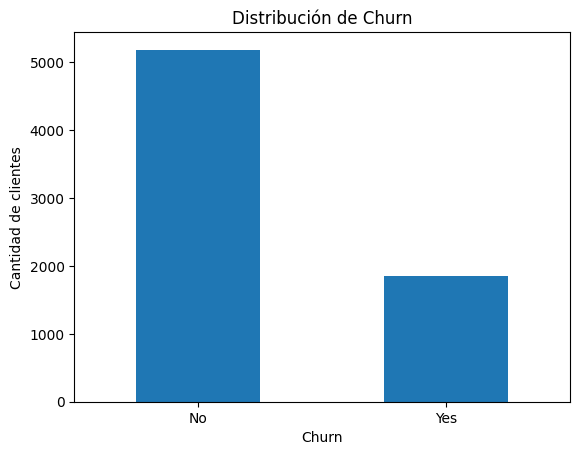

In [30]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

plt.show()

La clase `No` es claramente mayoritaria frente a la clase `Yes`.

El desbalance no es extremo, pero debe tenerse en cuenta al momento de entrenar y evaluar los modelos.

In [31]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,61.270008,38.729992
One year,85.026385,14.973615
Two year,91.025641,8.974359


### Relación entre tipo de contrato y Churn

Se observa una diferencia importante en la tasa de abandono según el tipo de contrato.

- Los clientes con contrato **Month-to-month** presentan una tasa de churn de aproximadamente **38,73%**.
- Los clientes con contrato de **One year** presentan una tasa cercana al **14,97%**.
- Los clientes con contrato de **Two year** presentan la menor tasa de churn, con aproximadamente **8,97%**.

Esto sugiere que el tipo de contrato podría ser una variable relevante para predecir el abandono. Los contratos de mayor duración parecen estar asociados con una mayor permanencia del cliente.

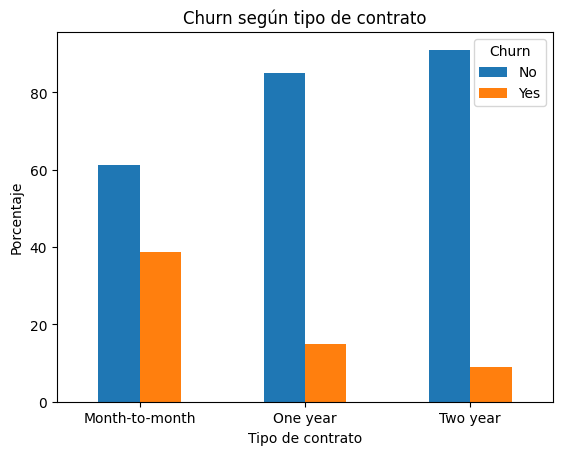

In [32]:
tabla_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

tabla_contract.plot(kind="bar")

plt.title("Churn según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [33]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.278249
Yes,29.276252


In [34]:
df.groupby("Churn")["tenure"].median()

,tenure
Churn,
No,38.0
Yes,27.0


### Relación entre antigüedad y Churn

La variable `tenure` representa la antigüedad del cliente.

Se observa que los clientes que permanecen en la empresa presentan una antigüedad mayor:

- Churn = No: media de **37,28 meses** y mediana de **38 meses**.
- Churn = Yes: media de **29,28 meses** y mediana de **27 meses**.

Esto sugiere que los clientes con menor antigüedad presentan una mayor tendencia al abandono.

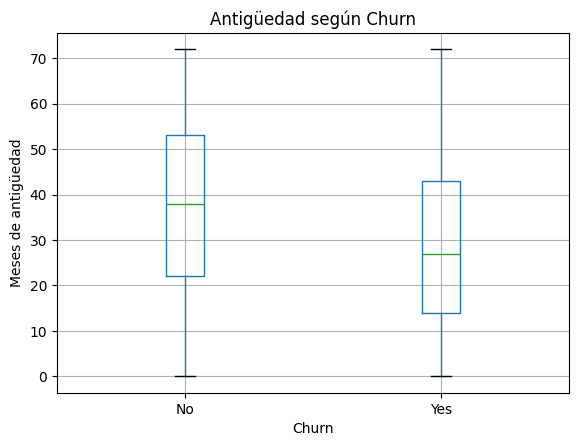

In [35]:
df.boxplot(column="tenure", by="Churn")

plt.title("Antigüedad según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Meses de antigüedad")

plt.show()

In [36]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,63.940046
Yes,79.977216


In [37]:
df.groupby("Churn")["MonthlyCharges"].median()

,MonthlyCharges
Churn,
No,69.305
Yes,84.690


### Relación entre cargos mensuales y Churn

Se observa que los clientes que abandonan el servicio presentan cargos mensuales más altos.

- Churn = No: media de **63,94** y mediana de **69,31**.
- Churn = Yes: media de **79,98** y mediana de **84,69**.

Esto sugiere que `MonthlyCharges` puede ser una variable relevante para explicar el abandono, ya que los clientes con cargos mensuales más elevados muestran una mayor tendencia al churn.

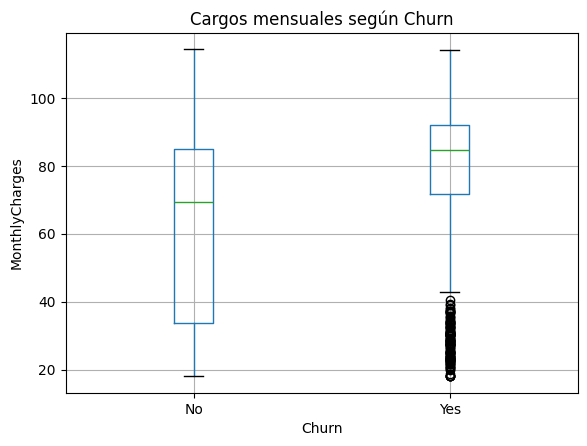

In [38]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Cargos mensuales según Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")

plt.show()

In [39]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,80.034350,19.965650
Fiber optic,59.747235,40.252765
No,92.382182,7.617818


### Relación entre servicio de Internet y Churn

Se observa una diferencia importante en la tasa de abandono según el tipo de servicio de Internet.

- Los clientes con **DSL** presentan una tasa de churn de aproximadamente **19,97%**.
- Los clientes con **Fiber optic** presentan la tasa más alta, con aproximadamente **40,25%**.
- Los clientes que **no tienen servicio de Internet** presentan la tasa más baja, con aproximadamente **7,62%**.

Esto sugiere que `InternetService` puede ser una variable relevante para el modelo, especialmente por la alta proporción de abandono observada en los clientes con fibra óptica.

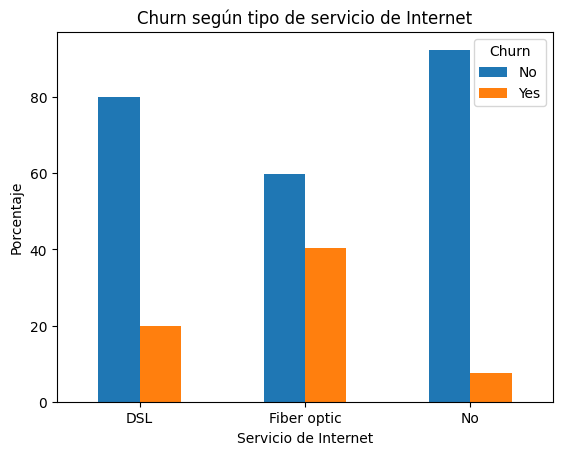

In [40]:
tabla_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

tabla_internet.plot(kind="bar")

plt.title("Churn según tipo de servicio de Internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [41]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,65.820490,34.179510
No internet service,92.382182,7.617818
Yes,72.173913,27.826087


### Relación entre soporte técnico y Churn

Se observa que los clientes que no cuentan con soporte técnico presentan una tasa de abandono mayor.

- Sin soporte técnico: churn de aproximadamente **34,18%**.
- Con soporte técnico: churn de aproximadamente **27,83%**.
- Sin servicio de Internet: churn de aproximadamente **7,62%**.

Esto sugiere que `TechSupport` podría aportar información útil al modelo, aunque su relación con el abandono parece menos marcada que la observada en variables como `Contract` o `InternetService`.

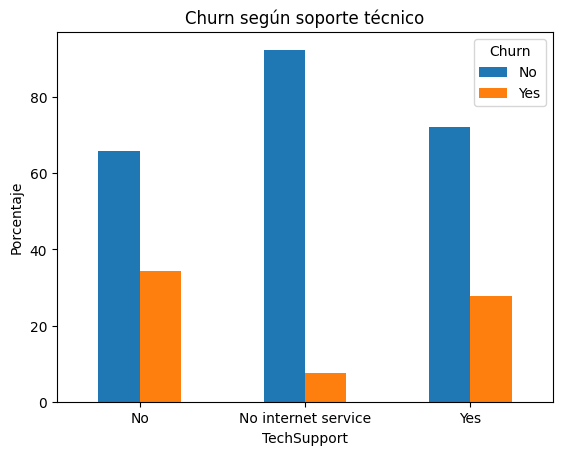

In [42]:
tabla_support = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tabla_support.plot(kind="bar")

plt.title("Churn según soporte técnico")
plt.xlabel("TechSupport")
plt.ylabel("Porcentaje")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [43]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),76.979742,23.020258
Credit card (automatic),75.433727,24.566273
Electronic check,68.943839,31.056161
Mailed check,75.614367,24.385633


### Relación entre método de pago y Churn

Se observan diferencias en la tasa de abandono según el método de pago utilizado.

- Bank transfer (automatic): churn de aproximadamente **23,02%**.
- Credit card (automatic): churn de aproximadamente **24,57%**.
- Electronic check: churn de aproximadamente **31,06%**.
- Mailed check: churn de aproximadamente **24,39%**.

El método `Electronic check` presenta la mayor tasa de churn, por lo que `PaymentMethod` podría aportar información relevante al modelo.

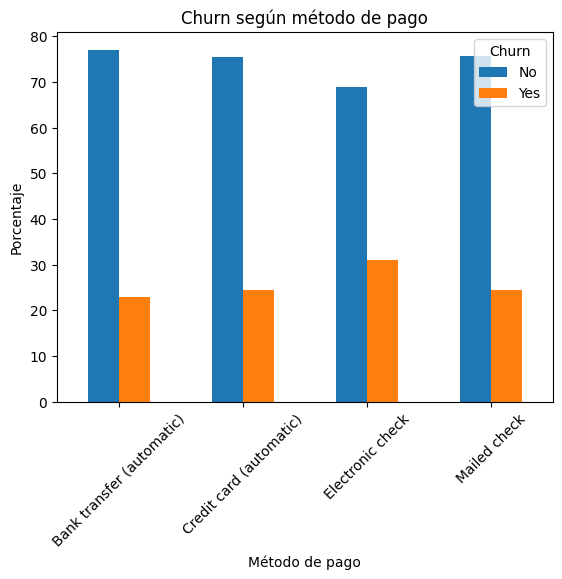

In [44]:
tabla_pago = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

tabla_pago.plot(kind="bar")

plt.title("Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45)
plt.legend(title="Churn")

plt.show()

## 7. Conclusiones del análisis exploratorio

El análisis inicial permitió identificar algunas variables que presentan diferencias relevantes respecto de la variable objetivo `Churn`.

Las principales observaciones fueron:

- El dataset contiene **7.043 registros y 21 variables**.
- Se detectaron **26 valores faltantes en `TotalCharges`**.
- No se encontraron registros duplicados.
- La variable objetivo presenta cierto desbalance: aproximadamente **73,63% No** y **26,37% Yes**.
- Los clientes con contrato `Month-to-month` presentan una tasa de churn considerablemente mayor.
- Los clientes que abandonan presentan, en promedio, menor antigüedad (`tenure`).
- Los clientes con churn presentan cargos mensuales (`MonthlyCharges`) más elevados.
- Los clientes con servicio `Fiber optic` presentan una tasa de abandono alta.
- Los clientes sin soporte técnico presentan mayor churn que aquellos que cuentan con soporte.
- El método de pago `Electronic check` presenta una tasa de abandono superior al resto.

Estas observaciones sugieren que variables como `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `TechSupport` y `PaymentMethod` podrían resultar relevantes para la predicción de churn.

En la siguiente etapa se realizará la preparación de los datos y la construcción de un pipeline reproducible para el entrenamiento de modelos.

# Sección nueva

## 8. Preparación de los datos para modelado

A partir del análisis exploratorio se procede a preparar el dataset para el entrenamiento.

La variable `customerID` no se utilizará como predictor, ya que funciona únicamente como identificador del cliente.

La variable objetivo será `Churn`, mientras que el resto de las variables se utilizarán como características predictoras.

In [45]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7043, 19)
Dimensiones de y: (7043,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5634, 19)
Prueba: (1409, 19)


In [47]:
print("Distribución en TRAIN:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en TEST:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en TRAIN:
Churn
No     73.642173
Yes    26.357827
Name: proportion, dtype: float64

Distribución en TEST:
Churn
No     73.598297
Yes    26.401703
Name: proportion, dtype: float64


Se utilizó una división de **80% para entrenamiento y 20% para prueba**.

Se definió `random_state=42` para garantizar que la partición sea reproducible.

Además, se utilizó `stratify=y` para mantener una proporción similar de clientes con y sin churn en ambos conjuntos.

In [48]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [49]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [50]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [51]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## 9. Entrenamiento de modelos

Se comenzará con un modelo baseline para establecer un punto de referencia.

El baseline permitirá comparar si los modelos posteriores realmente mejoran respecto de una estrategia simple.

In [52]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


In [53]:
y_pred_dummy = dummy_model.predict(X_test)

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(y_test, y_pred_dummy))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_dummy))

Classification Report:
              precision    recall  f1-score   support

          No       0.74      1.00      0.85      1037
         Yes       0.00      0.00      0.00       372

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409

Matriz de confusión:
[[1037    0]
 [ 372    0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
y_prob_dummy = dummy_model.predict_proba(X_test)[:, 1]

roc_auc_dummy = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_dummy
)

print("ROC-AUC:", roc_auc_dummy)

ROC-AUC: 0.5


### Resultado del modelo baseline

El modelo `DummyClassifier` fue configurado para predecir siempre la clase más frecuente.

El resultado obtuvo una Accuracy aproximada de **0,74**, pero este valor resulta engañoso debido al desbalance de clases.

El modelo identificó correctamente todos los casos de `No`, pero no detectó ningún cliente con `Churn = Yes`.

Por este motivo:
- Recall para `Yes`: **0,00**
- F1-score para `Yes`: **0,00**
- ROC-AUC: **0,50**

Esto confirma que el baseline no tiene capacidad predictiva real y será utilizado únicamente como punto de referencia para comparar los siguientes modelos.

## 10. Modelo lineal - Logistic Regression

Se entrena un modelo de Regresión Logística utilizando el mismo pipeline de preprocesamiento.

Este modelo permitirá evaluar si existe una mejora respecto del baseline.

In [56]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression entrenado correctamente.")

Logistic Regression entrenado correctamente.


In [57]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

In [58]:
print("Classification Report:")
print(classification_report(y_test, y_pred_logistic))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_logistic))

roc_auc_logistic = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_logistic
)

print("ROC-AUC:", roc_auc_logistic)

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.92      0.87      1037
         Yes       0.66      0.45      0.54       372

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

Matriz de confusión:
[[952  85]
 [205 167]]
ROC-AUC: 0.8119601621716905


### Resultado de Logistic Regression

La Regresión Logística mejoró claramente respecto del modelo baseline.

Obtuvo una Accuracy aproximada de **0,79** y un ROC-AUC de **0,81**.

Para la clase `Churn = Yes` obtuvo:

- Precision: **0,66**
- Recall: **0,45**
- F1-score: **0,54**

El modelo logró detectar 167 clientes que efectivamente abandonaron el servicio, aunque todavía dejó sin detectar 205 casos de churn.

Esto muestra que el modelo tiene capacidad predictiva real, pero todavía presenta margen de mejora, especialmente en Recall para la clase positiva.

### Comparación con el baseline

El baseline obtenía una Accuracy cercana a 0,74, pero no detectaba ningún caso de churn.

La Regresión Logística mejora el desempeño general y, principalmente, logra identificar parte de los clientes con riesgo de abandono.

Por este motivo, resulta claramente superior al modelo baseline.

In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest entrenado correctamente.")

Random Forest entrenado correctamente.


In [60]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [61]:
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_rf
)

print("ROC-AUC:", roc_auc_rf)

Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.92      0.86      1037
         Yes       0.63      0.40      0.49       372

    accuracy                           0.78      1409
   macro avg       0.72      0.66      0.67      1409
weighted avg       0.76      0.78      0.76      1409

Matriz de confusión:
[[952  85]
 [225 147]]
ROC-AUC: 0.7916588898912289


### Resultado de Random Forest

El modelo Random Forest obtuvo un desempeño aceptable, aunque inferior a la Regresión Logística en las métricas principales.

Para la clase `Churn = Yes` obtuvo:

- Precision: **0,63**
- Recall: **0,40**
- F1-score: **0,49**
- ROC-AUC: **0,79**

El modelo identificó correctamente 147 casos de churn, pero dejó sin detectar 225 clientes que efectivamente abandonaron el servicio.

En esta primera comparación, Random Forest no supera a Logistic Regression.

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def obtener_metricas(nombre, y_true, y_pred, y_prob):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Yes": precision_score(y_true, y_pred, pos_label="Yes"),
        "Recall_Yes": recall_score(y_true, y_pred, pos_label="Yes"),
        "F1_Yes": f1_score(y_true, y_pred, pos_label="Yes"),
        "ROC_AUC": roc_auc_score(
            (y_true == "Yes").astype(int),
            y_prob
        )
    }

resultados = pd.DataFrame([
    obtener_metricas(
        "DummyClassifier",
        y_test,
        y_pred_dummy,
        y_prob_dummy
    ),
    obtener_metricas(
        "LogisticRegression",
        y_test,
        y_pred_logistic,
        y_prob_logistic
    ),
    obtener_metricas(
        "RandomForest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
])

resultados

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Modelo,Accuracy,Precision_Yes,Recall_Yes,F1_Yes,ROC_AUC
0,DummyClassifier,0.735983,0.000000,0.000000,0.000000,0.500000
1,LogisticRegression,0.794180,0.662698,0.448925,0.535256,0.811960
2,RandomForest,0.779986,0.633621,0.395161,0.486755,0.791659


## 12. Comparación inicial de modelos

La Regresión Logística presenta el mejor desempeño general entre los tres modelos evaluados.

Además de superar al baseline, obtiene mejores valores de Recall, F1-score y ROC-AUC que Random Forest para la clase `Churn = Yes`.

Por el momento, Logistic Regression se considera el mejor modelo candidato.

Sin embargo, antes de realizar la selección definitiva se probarán configuraciones adicionales de los modelos.

In [63]:
logistic_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

logistic_balanced.fit(X_train, y_train)

y_pred_log_bal = logistic_balanced.predict(X_test)
y_prob_log_bal = logistic_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log_bal))

roc_auc_log_bal = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_log_bal
)

print("ROC-AUC:", roc_auc_log_bal)
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_log_bal))

              precision    recall  f1-score   support

          No       0.88      0.72      0.79      1037
         Yes       0.48      0.72      0.58       372

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.77      0.72      0.73      1409

ROC-AUC: 0.8116335376033015
Matriz de confusión:
[[747 290]
 [104 268]]


### Logistic Regression con clases balanceadas

Se probó una segunda configuración de Regresión Logística utilizando `class_weight="balanced"`.

Los resultados fueron:

- Accuracy: **0,72**
- Precision para Churn = Yes: **0,48**
- Recall para Churn = Yes: **0,72**
- F1-score para Churn = Yes: **0,58**
- ROC-AUC: **0,81**

La principal mejora se observa en el Recall de la clase positiva, que aumenta de aproximadamente **0,45 a 0,72** respecto de la Regresión Logística original.

Esto implica que el modelo balanceado detecta una mayor cantidad de clientes que efectivamente abandonan el servicio.

Como contrapartida, aumenta la cantidad de falsos positivos y disminuye la Accuracy general.

### Impacto de los falsos negativos

En este problema, un falso negativo ocurre cuando el modelo clasifica a un cliente como estable, pero ese cliente realmente abandona el servicio.

Este tipo de error puede ser especialmente costoso para el negocio, ya que la empresa pierde la oportunidad de aplicar una acción de retención.

Por este motivo, un modelo con mayor Recall para `Churn = Yes` puede ser preferible, incluso si sacrifica parte de la Accuracy o de la Precision.

In [64]:
rf_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_bal))

roc_auc_rf_bal = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_rf_bal
)

print("ROC-AUC:", roc_auc_rf_bal)
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_bal))

              precision    recall  f1-score   support

          No       0.81      0.92      0.86      1037
         Yes       0.64      0.38      0.48       372

    accuracy                           0.78      1409
   macro avg       0.72      0.65      0.67      1409
weighted avg       0.76      0.78      0.76      1409

ROC-AUC: 0.7909291691293122
Matriz de confusión:
[[959  78]
 [231 141]]


### Random Forest con clases balanceadas

Se probó una variante de Random Forest utilizando `class_weight="balanced"`.

Los resultados obtenidos fueron:

- Accuracy: **0,78**
- Precision para Churn = Yes: **0,64**
- Recall para Churn = Yes: **0,38**
- F1-score para Churn = Yes: **0,48**
- ROC-AUC: **0,79**

En comparación con el Random Forest original, esta configuración no produjo una mejora relevante. El Recall de la clase positiva incluso disminuyó ligeramente.

Por este motivo, esta variante no se considera mejor candidata que los modelos anteriores.

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [66]:
rf_depth = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        random_state=42
    ))
])

rf_depth.fit(X_train, y_train)

y_pred_rf_depth = rf_depth.predict(X_test)
y_prob_rf_depth = rf_depth.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_depth))

roc_auc_rf_depth = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_rf_depth
)

print("ROC-AUC:", roc_auc_rf_depth)
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf_depth))

              precision    recall  f1-score   support

          No       0.81      0.94      0.87      1037
         Yes       0.68      0.38      0.49       372

    accuracy                           0.79      1409
   macro avg       0.75      0.66      0.68      1409
weighted avg       0.78      0.79      0.77      1409

ROC-AUC: 0.802062919297809
Matriz de confusión:
[[971  66]
 [229 143]]


### Random Forest con profundidad limitada

Se probó una variante de Random Forest limitando la profundidad del árbol y aumentando el mínimo de muestras necesarias para dividir un nodo.

Los resultados obtenidos fueron:

- Accuracy: **0,79**
- Precision para Churn = Yes: **0,68**
- Recall para Churn = Yes: **0,38**
- F1-score para Churn = Yes: **0,49**
- ROC-AUC: **0,80**

La configuración mejora levemente algunas métricas respecto del Random Forest original, especialmente Precision y ROC-AUC.

Sin embargo, el Recall para la clase positiva continúa siendo bajo, por lo que el modelo deja sin detectar una cantidad importante de clientes que efectivamente abandonan el servicio.

In [67]:
resultados_finales = pd.DataFrame([
    {
        "Modelo": "DummyClassifier",
        "Accuracy": 0.74,
        "Precision_Yes": 0.00,
        "Recall_Yes": 0.00,
        "F1_Yes": 0.00,
        "ROC_AUC": 0.50
    },
    {
        "Modelo": "LogisticRegression",
        "Accuracy": 0.79,
        "Precision_Yes": 0.66,
        "Recall_Yes": 0.45,
        "F1_Yes": 0.54,
        "ROC_AUC": 0.812
    },
    {
        "Modelo": "RandomForest",
        "Accuracy": 0.78,
        "Precision_Yes": 0.63,
        "Recall_Yes": 0.40,
        "F1_Yes": 0.49,
        "ROC_AUC": 0.792
    },
    {
        "Modelo": "LogisticRegression Balanced",
        "Accuracy": 0.72,
        "Precision_Yes": 0.48,
        "Recall_Yes": 0.72,
        "F1_Yes": 0.58,
        "ROC_AUC": 0.812
    },
    {
        "Modelo": "RandomForest Balanced",
        "Accuracy": 0.78,
        "Precision_Yes": 0.64,
        "Recall_Yes": 0.38,
        "F1_Yes": 0.48,
        "ROC_AUC": 0.791
    },
    {
        "Modelo": "RandomForest Depth",
        "Accuracy": 0.79,
        "Precision_Yes": 0.68,
        "Recall_Yes": 0.38,
        "F1_Yes": 0.49,
        "ROC_AUC": 0.802
    }
])

resultados_finales

,Modelo,Accuracy,Precision_Yes,Recall_Yes,F1_Yes,ROC_AUC
0,DummyClassifier,0.74,0.00,0.00,0.00,0.500
1,LogisticRegression,0.79,0.66,0.45,0.54,0.812
2,RandomForest,0.78,0.63,0.40,0.49,0.792
3,LogisticRegression Balanced,0.72,0.48,0.72,0.58,0.812
4,RandomForest Balanced,0.78,0.64,0.38,0.48,0.791
5,RandomForest Depth,0.79,0.68,0.38,0.49,0.802


## 13. Selección preliminar del modelo candidato

Se evaluaron seis configuraciones diferentes.

La Regresión Logística estándar presenta un buen equilibrio general entre Accuracy, Precision, Recall, F1-score y ROC-AUC.

Sin embargo, la variante `LogisticRegression` con `class_weight="balanced"` logra un Recall considerablemente mayor para la clase `Churn = Yes`.

Esto resulta especialmente relevante para el problema de negocio, ya que un falso negativo implica clasificar como estable a un cliente que realmente abandonará el servicio.

Por este motivo, la Regresión Logística balanceada se considera, en esta etapa, el modelo candidato principal, aunque su menor Precision y Accuracy representan un costo que debe ser considerado.

La elección final se justificará priorizando la detección de clientes en riesgo de abandono.

# Sección nueva

In [68]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [69]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("customer-churn-experiments")

print("MLflow configurado correctamente.")

2026/09/14 23:34:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/14 23:34:38 INFO mlflow.store.db.utils: Updating database tables
2026/09/14 23:34:44 INFO mlflow.tracking.fluent: Experiment with name 'customer-churn-experiments' does not exist. Creating a new experiment.


MLflow configurado correctamente.


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def registrar_modelo_mlflow(nombre_run, modelo, parametros):

    # Predicciones
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="Yes",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="Yes",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="Yes",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        (y_test == "Yes").astype(int),
        y_prob
    )

    # Run de MLflow
    with mlflow.start_run(run_name=nombre_run):

        # Parámetros
        mlflow.log_params(parametros)

        # Métricas
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision_yes", precision)
        mlflow.log_metric("recall_yes", recall)
        mlflow.log_metric("f1_yes", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        # Modelo
        mlflow.sklearn.log_model(
            sk_model=modelo,
            name="model",
            serialization_format="cloudpickle"
        )

        print(f"Run registrado correctamente: {nombre_run}")

In [71]:
registrar_modelo_mlflow(
    "01_DummyClassifier",
    dummy_model,
    {
        "modelo": "DummyClassifier",
        "strategy": "most_frequent"
    }
)

2026/09/14 23:34:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 01_DummyClassifier


In [72]:
registrar_modelo_mlflow(
    "02_LogisticRegression",
    logistic_model,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "None",
        "random_state": 42
    }
)

2026/09/14 23:34:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 02_LogisticRegression


In [73]:
registrar_modelo_mlflow(
    "03_RandomForest",
    rf_model,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 200,
        "class_weight": "None",
        "random_state": 42
    }
)

2026/09/14 23:35:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 03_RandomForest


In [74]:
registrar_modelo_mlflow(
    "04_LogisticRegression_Balanced",
    logistic_balanced,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "balanced",
        "random_state": 42
    }
)

2026/09/14 23:35:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 04_LogisticRegression_Balanced


In [75]:
registrar_modelo_mlflow(
    "05_RandomForest_Balanced",
    rf_balanced,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 200,
        "class_weight": "balanced",
        "random_state": 42
    }
)

2026/09/14 23:35:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 05_RandomForest_Balanced


In [76]:
registrar_modelo_mlflow(
    "06_RandomForest_Depth",
    rf_depth,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_split": 10,
        "random_state": 42
    }
)

2026/09/14 23:35:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado correctamente: 06_RandomForest_Depth


In [77]:
experiment = mlflow.get_experiment_by_name("customer-churn-experiments")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision_yes",
        "metrics.recall_yes",
        "metrics.f1_yes",
        "metrics.roc_auc"
    ]
]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision_yes,metrics.recall_yes,metrics.f1_yes,metrics.roc_auc
0,170e253ca4074a43955465ac6fa1b461,06_RandomForest_Depth,0.790632,0.684211,0.384409,0.492255,0.802063
1,fc2da00df096485e90f7a8c116d79635,05_RandomForest_Balanced,0.780696,0.643836,0.379032,0.477157,0.790929
2,0c8e4bf571864b41ad435e69e4c74d7a,04_LogisticRegression_Balanced,0.720369,0.480287,0.720430,0.576344,0.811634
3,034d18c3e5b84591b3bc84bb51284a9a,03_RandomForest,0.779986,0.633621,0.395161,0.486755,0.791659
4,c3bdf037a4104514bc787bd522839e0d,02_LogisticRegression,0.794180,0.662698,0.448925,0.535256,0.811960
5,a5b15ff5ed3741e196b9bf01451bb343,01_DummyClassifier,0.735983,0.000000,0.000000,0.000000,0.500000


In [78]:
runs[
    [
        "tags.mlflow.runName",
        "metrics.accuracy",
        "metrics.precision_yes",
        "metrics.recall_yes",
        "metrics.f1_yes",
        "metrics.roc_auc"
    ]
].sort_values(
    by="metrics.recall_yes",
    ascending=False
)

,tags.mlflow.runName,metrics.accuracy,metrics.precision_yes,metrics.recall_yes,metrics.f1_yes,metrics.roc_auc
2,04_LogisticRegression_Balanced,0.720369,0.480287,0.720430,0.576344,0.811634
4,02_LogisticRegression,0.794180,0.662698,0.448925,0.535256,0.811960
3,03_RandomForest,0.779986,0.633621,0.395161,0.486755,0.791659
0,06_RandomForest_Depth,0.790632,0.684211,0.384409,0.492255,0.802063
1,05_RandomForest_Balanced,0.780696,0.643836,0.379032,0.477157,0.790929
5,01_DummyClassifier,0.735983,0.000000,0.000000,0.000000,0.500000


In [79]:
import os
from google.colab import userdata

REPO_DIR = "/content/customer-churn-ml"

if not os.path.exists(REPO_DIR):
    token = userdata.get('GITHUB_TOKEN')
    !git clone https://{token}@github.com/Francopaz62/customer-churn-ml.git {REPO_DIR}

os.chdir(REPO_DIR)
print(os.getcwd())

/content/customer-churn-ml


In [80]:
!mkdir -p data/raw notebooks src/data src/features src/training src/evaluation src/inference app tests monitoring models scripts
!touch src/data/.gitkeep src/features/.gitkeep src/training/.gitkeep src/evaluation/.gitkeep src/inference/.gitkeep app/.gitkeep tests/.gitkeep monitoring/.gitkeep models/.gitkeep scripts/.gitkeep
!ls -la

total 920
drwxr-xr-x 12 root root   4096 Sep 14 23:35 .
drwxr-xr-x  1 root root   4096 Sep 14 23:17 ..
drwxr-xr-x  2 root root   4096 Sep 14 23:18 app
drwxr-xr-x  3 root root   4096 Sep 14 23:18 data
drwxr-xr-x  8 root root   4096 Sep 14 23:17 .git
-rw-r--r--  1 root root   4628 Sep 14 23:17 .gitignore
-rw-r--r--  1 root root 876544 Sep 14 23:35 mlflow.db
drwxr-xr-x  3 root root   4096 Sep 14 23:34 mlruns
drwxr-xr-x  2 root root   4096 Sep 14 23:18 models
drwxr-xr-x  2 root root   4096 Sep 14 23:18 monitoring
drwxr-xr-x  2 root root   4096 Sep 14 23:18 notebooks
-rw-r--r--  1 root root    562 Sep 14 23:17 README.md
drwxr-xr-x  2 root root   4096 Sep 14 23:18 scripts
drwxr-xr-x  7 root root   4096 Sep 14 23:18 src
drwxr-xr-x  2 root root   4096 Sep 14 23:18 tests


In [81]:
import shutil, glob, os

# Buscar el CSV donde sea que haya quedado, sin importar el nombre del zip
csv_encontrado = glob.glob("ISTEA_Proyecto_Churn_Datos/**/customer_churn_historical.csv", recursive=True)
print("Encontrado:", csv_encontrado)

# Copiarlo al lugar definitivo del repo
shutil.copy(csv_encontrado[0], "data/raw/customer_churn_historical.csv")
print("Copiado a data/raw/")

# Limpiar los zips y la carpeta temporal, ya no hacen falta
for z in glob.glob("*.zip"):
    os.remove(z)
shutil.rmtree("ISTEA_Proyecto_Churn_Datos")

print(os.listdir("data/raw"))

Encontrado: []


IndexError: list index out of range

In [83]:
!git config --global user.email "francopaz62@ejemplo.com"
!git config --global user.name "Francopaz62"

In [84]:
!git add data/raw/customer_churn_historical.csv
!git commit -m "Agregar dataset historico de Customer Churn"
!git push

[main 4767efc] Agregar dataset historico de Customer Churn
 1 file changed, 7044 insertions(+)
 create mode 100644 data/raw/customer_churn_historical.csv
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (5/5), 171.53 KiB | 4.51 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Francopaz62/customer-churn-ml.git
   1210b83..4767efc  main -> main


In [ ]:
# 1. Guardar una copia del notebook actual dentro de la carpeta notebooks/ del repo
from google.colab import _message
notebook_json = _message.blocking_request('get_ipynb')['ipynb']

import json
with open("notebooks/eda_experimentacion.ipynb", "w") as f:
    json.dump(notebook_json, f)

print("Notebook guardado en notebooks/")